# NHA Hackathon – Problem Statement 3  
---
### Team: Nikhileswara Rao Sulake, Sai Manikanta Eswar Machara, Sivalal Kethavath
### Rajiv Gandhi University of Knowledge Technologies, Nuzvid, Andhra Pradesh
---

This pipeline is completely classicical computer vision based solution, where no models or other components are required, just using the traditional pre-defined library our solution is capable enough to detect the document forgery. This solution got 0.5315 score in the internal validation placing at Top3 in the leaderbaord. 

Why we choose this classical CV solution than the huge CLIP's, ViT's, ManTra-Net, MVSS-Net, CAT-Net or DTD? Because our main motive is making the solution highly scalable, computationally lightweight, and 100% explainable, aligning perfectly with the core demands of the AB-PMJAY ecosystem.

In [32]:
import os
from pathlib import Path
import pytesseract
import shutil

fallback_path = Path(r"C:\Program Files\Tesseract-OCR\tesseract.exe")
found = shutil.which("tesseract")
if not found and fallback_path.exists():
    found = str(fallback_path)

if found:
    os.environ["TESSERACT_CMD"] = found
    pytesseract.pytesseract.tesseract_cmd = found

print("Tesseract cmd:", found)

Tesseract cmd: C:\Program Files\Tesseract-OCR\tesseract.exe


In [33]:
from pathlib import Path
import sys
import re
import shutil

import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd()
if not (repo_root / "backend").exists():
    repo_root = repo_root.parent

backend_dir = repo_root / "backend"
if str(backend_dir) not in sys.path:
    sys.path.insert(0, str(backend_dir))

from app.pipeline import run_pipeline, CATEGORY_IDS, is_ocr_enabled
from PIL import Image

IMAGE_PATH = Path(r"C:\Users\nikhi\Downloads\sample_data\1.png")
PRESET = "npv_focus"
work_dir = repo_root / "backend_sample_testing" / "work_fair"
if work_dir.exists():
    shutil.rmtree(work_dir)
work_dir.mkdir(parents=True, exist_ok=True)

print("Repo:", repo_root)
print("Image exists:", IMAGE_PATH.exists())
print("OCR enabled:", is_ocr_enabled())
print("Preset:", PRESET)

Repo: c:\Users\nikhi\Downloads\Doc-Forgery-Detector
Image exists: True
OCR enabled: True
Preset: npv_focus


In [34]:
import copy

from app.pipeline import DETECTOR_TUNING, set_tuning_preset

base_name = "strict"
base = DETECTOR_TUNING.get(base_name, DETECTOR_TUNING["normal"])
npv_focus = copy.deepcopy(base)

c2 = npv_focus["c2"]
c2.update({
    "edge_z": 3.6,
    "stroke_z": 3.6,
    "ocr_edge_density": 0.35,
    "min_region_area": 260,
    "min_line_components": 5,
    "component_min_area": 170,
})

c3 = npv_focus["c3"]
c3.update({
    "component_min_area": 320,
    "min_candidate_area": 520,
    "stamp_circularity": 0.72,
    "stamp_fill": 0.38,
    "signature_aspect": 5.0,
    "signature_fill_max": 0.18,
    "fill_min": 0.55,
    "ocr_min_area": 260,
    "min_region_area": 260,
})

c4 = npv_focus["c4"]
c4.update({
    "gap_min_abs": 18.0,
    "gap_median_mult": 2.6,
    "gap_token_width_mult": 0.9,
    "smooth_percentile": 20,
    "smooth_min_area": 320,
    "smooth_min_dim": 10,
    "score_threshold": 3.2,
    "min_region_area": 240,
    "ring_var_ratio": 0.55,
    "ring_grad_ratio": 0.55,
    "ring_res_ratio": 0.6,
    "ring_fg_delta": 0.12,
    "erased_text_bonus": 0.3,
})

c7 = npv_focus["c7"]
c7.update({
    "min_tokens_page": 6,
    "min_tokens_per_line": 6,
    "min_gaps_per_line": 4,
    "med_gap_min": 6.0,
    "mad_gap_min": 1.4,
    "gap_cv_max": 0.6,
    "min_token_width": 8,
    "large_gap_min_abs": 18.0,
    "large_gap_median_mult": 2.8,
    "large_gap_z": 4.2,
    "large_gap_line_ratio_max": 0.22,
    "tight_gap_median_mult": 0.34,
    "tight_gap_median_min": 12.0,
    "tight_gap_z": -3.6,
    "single_gap_median_mult": 4.6,
    "single_gap_min_abs": 28.0,
    "single_gap_min_tokens": 7,
})

c9 = npv_focus["c9"]
c9.update({
    "z_edge": 3.6,
    "z_grad": 3.6,
    "z_res": 3.6,
    "z_var": 3.6,
    "z_stroke": 3.6,
    "z_height": 3.8,
    "score_threshold": 3.8,
    "min_region_area": 260,
    "min_token_area_line": 140,
    "min_token_area_susp": 210,
    "min_line_tokens": 5,
    "ring_ratio_low": 0.45,
    "ring_ratio_high": 1.9,
    "fft_peak_min": 14.0,
    "fft_ratio_min": 2.8,
})

DETECTOR_TUNING["npv_focus"] = npv_focus
set_tuning_preset("npv_focus")

print("NPV focus tuning applied based on:", base_name)
print("C2:", {key: c2[key] for key in ("edge_z", "stroke_z", "ocr_edge_density", "min_region_area", "min_line_components", "component_min_area")})
print("C3:", {key: c3[key] for key in ("component_min_area", "min_candidate_area", "stamp_circularity", "stamp_fill", "signature_aspect", "signature_fill_max", "fill_min", "ocr_min_area", "min_region_area")})
print("C4:", {key: c4[key] for key in ("gap_min_abs", "gap_median_mult", "gap_token_width_mult", "smooth_percentile", "smooth_min_area", "smooth_min_dim", "score_threshold", "min_region_area", "ring_var_ratio", "ring_grad_ratio", "ring_res_ratio", "ring_fg_delta", "erased_text_bonus")})
print("C7:", {key: c7[key] for key in ("min_tokens_page", "min_tokens_per_line", "min_gaps_per_line", "med_gap_min", "mad_gap_min", "gap_cv_max", "min_token_width", "large_gap_min_abs", "large_gap_z")})
print("C9:", {key: c9[key] for key in ("score_threshold", "min_region_area", "min_token_area_line", "min_token_area_susp", "min_line_tokens", "z_edge", "z_grad", "z_res", "z_var", "z_stroke", "z_height")})

NPV focus tuning applied based on: strict
C2: {'edge_z': 3.6, 'stroke_z': 3.6, 'ocr_edge_density': 0.35, 'min_region_area': 260, 'min_line_components': 5, 'component_min_area': 170}
C3: {'component_min_area': 320, 'min_candidate_area': 520, 'stamp_circularity': 0.72, 'stamp_fill': 0.38, 'signature_aspect': 5.0, 'signature_fill_max': 0.18, 'fill_min': 0.55, 'ocr_min_area': 260, 'min_region_area': 260}
C4: {'gap_min_abs': 18.0, 'gap_median_mult': 2.6, 'gap_token_width_mult': 0.9, 'smooth_percentile': 20, 'smooth_min_area': 320, 'smooth_min_dim': 10, 'score_threshold': 3.2, 'min_region_area': 240, 'ring_var_ratio': 0.55, 'ring_grad_ratio': 0.55, 'ring_res_ratio': 0.6, 'ring_fg_delta': 0.12, 'erased_text_bonus': 0.3}
C7: {'min_tokens_page': 6, 'min_tokens_per_line': 6, 'min_gaps_per_line': 4, 'med_gap_min': 6.0, 'mad_gap_min': 1.4, 'gap_cv_max': 0.6, 'min_token_width': 8, 'large_gap_min_abs': 18.0, 'large_gap_z': 4.2}
C9: {'score_threshold': 3.8, 'min_region_area': 260, 'min_token_area_lin


##### **Databank ID for PS3: 1ae9a4db-6b53-4a17-8274-fd3818c3f2be**

In [35]:
output = run_pipeline(IMAGE_PATH, work_dir, preset=PRESET, enable_ocr=True)
pages = output["pages"]
results = output["results"]

print(f"Pages: {len(pages)} | Results: {len(results)}")
print("Output dir:", output["output_dir"])

Pages: 1 | Results: 1
Output dir: c:\Users\nikhi\Downloads\Doc-Forgery-Detector\backend_sample_testing\work_fair\output


In [36]:
from collections import defaultdict

def apply_npv_filter(results_list, pages_list, min_area_ratio=0.02, min_regions=4, focus_categories=None):
    focus_categories = focus_categories or {"C2", "C3", "C4", "C7", "C9"}
    page_map = {p.page_file_name: p for p in pages_list}
    filtered_results = []
    for res in results_list:
        page = page_map.get(res.file_name)
        page_area = None
        if page and page.image_width and page.image_height:
            page_area = float(page.image_width * page.image_height)
        category_area = defaultdict(float)
        category_count = defaultdict(int)
        for region in res.detected_regions:
            area = float(region.w * region.h)
            category_area[region.category_id] += area
            category_count[region.category_id] += 1
        keep_categories = []
        keep_regions = []
        for region in res.detected_regions:
            cat = region.category_id
            if cat in focus_categories and page_area:
                ratio = category_area[cat] / page_area
                if category_count[cat] < min_regions or ratio < min_area_ratio:
                    continue
            keep_regions.append(region)
        for cat in res.predicted_categories:
            if cat in focus_categories and page_area:
                ratio = category_area[cat] / page_area
                if category_count[cat] < min_regions or ratio < min_area_ratio:
                    continue
            keep_categories.append(cat)
        res.detected_regions = keep_regions
        res.predicted_categories = keep_categories or ["C10"]
        filtered_results.append(res)
    return filtered_results

results = apply_npv_filter(results, pages, min_area_ratio=0.02, min_regions=4)
print("NPV filter applied. Categories per page:", [r.predicted_categories for r in results])

NPV filter applied. Categories per page: [['C10']]


In [37]:
import os
import shutil
import sys
from pathlib import Path

try:
    import pytesseract
except Exception:
    pytesseract = None

try:
    import pandas as pd
except Exception:
    pd = None

repo_root = Path.cwd()
if not (repo_root / "backend").exists():
    repo_root = repo_root.parent
backend_dir = repo_root / "backend"
if str(backend_dir) not in sys.path:
    sys.path.insert(0, str(backend_dir))

if pytesseract is not None:
    tesseract_cmd = os.environ.get("TESSERACT_CMD")
    if not tesseract_cmd:
        tesseract_cmd = shutil.which("tesseract")
    if not tesseract_cmd:
        fallback = Path(r"C:\Program Files\Tesseract-OCR\tesseract.exe")
        if fallback.exists():
            tesseract_cmd = str(fallback)
    if tesseract_cmd:
        os.environ["TESSERACT_CMD"] = tesseract_cmd
        pytesseract.pytesseract.tesseract_cmd = tesseract_cmd

ocr_active = pytesseract is not None
print("OCR active:", ocr_active)

OCR_CONFIG = "--oem 3 --psm 6"
MERGE_GAP = 8
PADDING = 10


def boxes_close(a, b, gap: int) -> bool:
    return not (
        a[2] + gap < b[0]
        or b[2] + gap < a[0]
        or a[3] + gap < b[1]
        or b[3] + gap < a[1]
    )


def merge_box(a, b):
    return (min(a[0], b[0]), min(a[1], b[1]), max(a[2], b[2]), max(a[3], b[3]))


def merge_boxes(boxes, gap: int):
    clusters = [{"box": b, "count": 1} for b in boxes]
    if not clusters:
        return []
    changed = True
    while changed:
        changed = False
        merged = []
        while clusters:
            curr = clusters.pop()
            i = 0
            while i < len(clusters):
                if boxes_close(curr["box"], clusters[i]["box"], gap):
                    curr["box"] = merge_box(curr["box"], clusters[i]["box"])
                    curr["count"] += clusters[i]["count"]
                    clusters.pop(i)
                    changed = True
                else:
                    i += 1
            merged.append(curr)
        clusters = merged
    return clusters


def pad_box(box, pad: int, width: int, height: int):
    x1, y1, x2, y2 = box
    return (
        max(0, x1 - pad),
        max(0, y1 - pad),
        min(width, x2 + pad),
        min(height, y2 + pad),
    )


from app.pipeline import build_findings_summary

summary = build_findings_summary(
    pages,
    results,
    merge_gap=MERGE_GAP,
    padding=PADDING,
    ocr_config=OCR_CONFIG,
)

if pd is not None:
    display(pd.DataFrame(summary.get("findings", [])))
else:
    print(summary.get("findings", []))

print("Summary:")
print(summary.get("summary_text", ""))

sanity = summary.get("sanity")
if sanity:
    print("Sanity:", sanity)

OCR active: True


""


Summary:

Sanity: {'ocr_active': True, 'tesseract_cmd': 'C:\\Program Files\\Tesseract-OCR\\tesseract.exe', 'merge_gap': 8, 'padding': 10, 'pages': 1, 'results': 1, 'clusters': 0, 'source_boxes': 0, 'clusters_with_text': 0, 'source_boxes_with_text': 0}


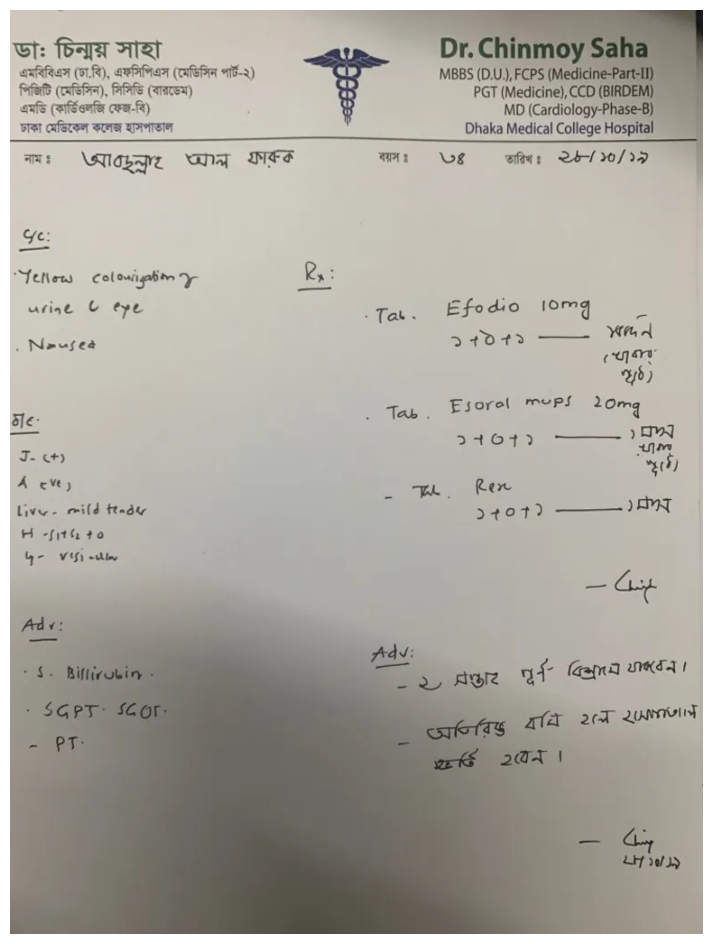

In [38]:
import matplotlib.patches as patches

page = pages[0]
image_path = Path(page.image_path or page.original_path)
image = Image.open(image_path).convert("RGB")

fig, ax = plt.subplots(figsize=(9, 12))
ax.imshow(image)

palette = [
    "#14868C",
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
]
color_map = {}

boxes_by_category = {}
for region in results[0].detected_regions:
    box = (region.x, region.y, region.x + region.w, region.y + region.h)
    boxes_by_category.setdefault(region.category_id, []).append(box)

for category_id, boxes in boxes_by_category.items():
    color = color_map.get(category_id)
    if color is None:
        color = palette[len(color_map) % len(palette)]
        color_map[category_id] = color

    clusters = merge_boxes(boxes, MERGE_GAP)
    for cluster in clusters:
        x1, y1, x2, y2 = cluster["box"]
        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2.5,
            edgecolor=color,
            facecolor="none",
        )
        ax.add_patch(rect)

        pad_box_coords = pad_box(cluster["box"], PADDING, image.width, image.height)
        px1, py1, px2, py2 = pad_box_coords
        padded_rect = patches.Rectangle(
            (px1, py1),
            px2 - px1,
            py2 - py1,
            linewidth=1.2,
            edgecolor=color,
            linestyle="--",
            facecolor="none",
            alpha=0.6,
        )
        ax.add_patch(padded_rect)

        ax.text(
            x1,
            max(0, y1 - 6),
            f"{category_id} x{cluster['count']}",
            color=color,
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7),
        )

ax.axis("off")
plt.show()

In [41]:
# Cell: Run baseline (strict) and npv_focus_test for both images and print concise findings
import os
from pathlib import Path
import shutil
import sys
import copy
from collections import defaultdict
repo_root = Path.cwd()
if not (repo_root / "backend").exists():
    repo_root = repo_root.parent
backend_dir = repo_root / "backend"
if str(backend_dir) not in sys.path:
    sys.path.insert(0, str(backend_dir))
# ensure tesseract path if available
fallback = Path(r"C:\Program Files\Tesseract-OCR\tesseract.exe")
found = os.environ.get("TESSERACT_CMD") or shutil.which("tesseract")
if not found and fallback.exists():
    found = str(fallback)
if found:
    os.environ["TESSERACT_CMD"] = found
from app.pipeline import run_pipeline, build_findings_summary, DETECTOR_TUNING, set_tuning_preset, is_ocr_enabled
IMAGE1 = Path(r"C:\Users\nikhi\Downloads\sample_data\1.png")
IMAGE2 = Path(r"C:\Users\nikhi\Downloads\sample_data\2cd1b800-8443-4309-af6c-a733f7b92735.jpeg")
work_dir = repo_root / "backend_sample_testing" / "work_fair" / "npv_test_runs"
if work_dir.exists():
    shutil.rmtree(work_dir)
work_dir.mkdir(parents=True, exist_ok=True)
print('OCR enabled:', is_ocr_enabled())
print('Image1 exists:', IMAGE1.exists())
print('Image2 exists:', IMAGE2.exists())
def run_report(preset_name, images):
    set_tuning_preset(preset_name)
    reports = {}
    for img in images:
        out = run_pipeline(img, work_dir, preset=preset_name, enable_ocr=True)
        pages = out.get('pages', [])
        results = out.get('results', [])
        rep = []
        for res in results:
            counts = {}
            for r in res.detected_regions:
                counts[r.category_id] = counts.get(r.category_id, 0) + 1
            rep.append({'file': res.file_name, 'categories': list(res.predicted_categories), 'region_counts': counts})
        summary = build_findings_summary(pages, results)
        reports[str(img)] = {'report': rep, 'summary_text': summary.get('summary_text', ''), 'sanity': summary.get('sanity', {})}
    return reports
# Baseline (strict)
baseline = run_report('strict', [IMAGE1, IMAGE2])
print('Baseline (strict) results:')
import json
print(json.dumps(baseline, indent=2))
# Create npv_focus_test based on strict and adjust C8/C9 plus earlier npv tweaks
base = DETECTOR_TUNING.get('strict', DETECTOR_TUNING.get('normal'))
npv_focus = copy.deepcopy(base)
npv_focus['c2'].update({'edge_z': 3.6, 'stroke_z': 3.6, 'ocr_edge_density': 0.35, 'min_region_area': 260, 'min_line_components': 5, 'component_min_area': 170})
npv_focus['c3'].update({'component_min_area': 320, 'min_candidate_area': 520, 'stamp_circularity': 0.72, 'stamp_fill': 0.38, 'signature_aspect': 5.0, 'signature_fill_max': 0.18, 'fill_min': 0.55, 'ocr_min_area': 260, 'min_region_area': 260})
npv_focus['c4'].update({'gap_min_abs': 18.0, 'gap_median_mult': 2.6, 'gap_token_width_mult': 0.9, 'smooth_percentile': 20, 'smooth_min_area': 320, 'smooth_min_dim': 10, 'score_threshold': 3.2, 'min_region_area': 240})
npv_focus['c7'].update({'min_tokens_page': 6, 'min_tokens_per_line': 6, 'min_gaps_per_line': 4})
# Make C8 more conservative to avoid false positives on originals
npv_focus['c8'].update({'score_threshold': 4.0, 'coverage_min': 0.5, 'line_coverage_min': 0.6, 'coverage_high_min': 0.75, 'spec_peak_min': 15.0, 'spec_highfreq_min': 3.0, 'text_density_min': 0.012})
# Strengthen C9 so it triggers on clear edits but not small noise
npv_focus['c9'].update({'z_edge': 3.0, 'z_grad': 3.0, 'z_res': 3.0, 'z_var': 3.0, 'z_stroke': 3.0, 'z_height': 3.2, 'score_threshold': 3.2, 'min_region_area': 200, 'min_line_tokens': 3})
DETECTOR_TUNING['npv_focus_test'] = npv_focus
# Run npv_focus_test
npv_results = run_report('npv_focus_test', [IMAGE1, IMAGE2])
print('npv_focus_test raw results:')
print(json.dumps(npv_results, indent=2))
# Apply notebook-style post-filter to the npv_focus_test run (min_area_ratio=0.02,min_regions=4)
def apply_npv_filter(results_list, pages_list, min_area_ratio=0.02, min_regions=4, focus_categories=None):
    focus_categories = focus_categories or {"C2", "C3", "C4", "C7", "C9", "C8"}
    page_map = {p.page_file_name: p for p in pages_list}
    filtered_results = []
    for res in results_list:
        page = page_map.get(res.file_name)
        page_area = None
        if page and page.image_width and page.image_height:
            page_area = float(page.image_width * page.image_height)
        category_area = defaultdict(float)
        category_count = defaultdict(int)
        for region in res.detected_regions:
            area = float(region.w * region.h)
            category_area[region.category_id] += area
            category_count[region.category_id] += 1
        keep_categories = []
        keep_regions = []
        for region in res.detected_regions:
            cat = region.category_id
            if cat in focus_categories and page_area:
                ratio = category_area[cat] / page_area
                if category_count[cat] < min_regions or ratio < min_area_ratio:
                    continue
            keep_regions.append(region)
        for cat in res.predicted_categories:
            if cat in focus_categories and page_area:
                ratio = category_area[cat] / page_area
                if category_count[cat] < min_regions or ratio < min_area_ratio:
                    continue
            keep_categories.append(cat)
        res.detected_regions = keep_regions
        res.predicted_categories = keep_categories or ["C10"]
        filtered_results.append(res)
    return filtered_results
# Re-run pipeline to obtain PageAnalysisResult objects and filter them
set_tuning_preset('npv_focus_test')
filtered_reports = {}
for img in [IMAGE1, IMAGE2]:
    out = run_pipeline(img, work_dir, preset='npv_focus_test', enable_ocr=True)
    pages = out.get('pages', [])
    results = out.get('results', [])
    results_filtered = apply_npv_filter(results, pages, min_area_ratio=0.02, min_regions=4)
    summary = build_findings_summary(pages, results_filtered)
    rep = []
    for res in results_filtered:
        counts = {}
        for r in res.detected_regions:
            counts[r.category_id] = counts.get(r.category_id, 0) + 1
        rep.append({'file': res.file_name, 'categories': list(res.predicted_categories), 'region_counts': counts})
    filtered_reports[str(img)] = {'report': rep, 'summary_text': summary.get('summary_text', ''), 'sanity': summary.get('sanity', {})}
print('npv_focus_test filtered results:')
print(json.dumps(filtered_reports, indent=2))

OCR enabled: True
Image1 exists: True
Image2 exists: True
Baseline (strict) results:
{
  "C:\\Users\\nikhi\\Downloads\\sample_data\\1.png": {
    "report": [
      {
        "file": "1.png",
        "categories": [
          "C2",
          "C3",
          "C4",
          "C9"
        ],
        "region_counts": {
          "C2": 23,
          "C3": 1,
          "C4": 39,
          "C9": 1
        }
      }
    ],
    "summary_text": "Page 1: Overwritten text near \"MD (Cardiology: Dhaka Medical College\" appears altered.\nPage 1: Added content in top-left appears altered.\nPage 1: Removed content near \"- ( ) omy . eee mild tend\" appears altered.\nPage 1: AI-edited content in top-center appears altered.",
    "sanity": {
      "ocr_active": true,
      "tesseract_cmd": "C:\\Program Files\\Tesseract-OCR\\tesseract.exe",
      "merge_gap": 8,
      "padding": 10,
      "pages": 1,
      "results": 1,
      "clusters": 47,
      "source_boxes": 64,
      "clusters_with_text": 4,
      "

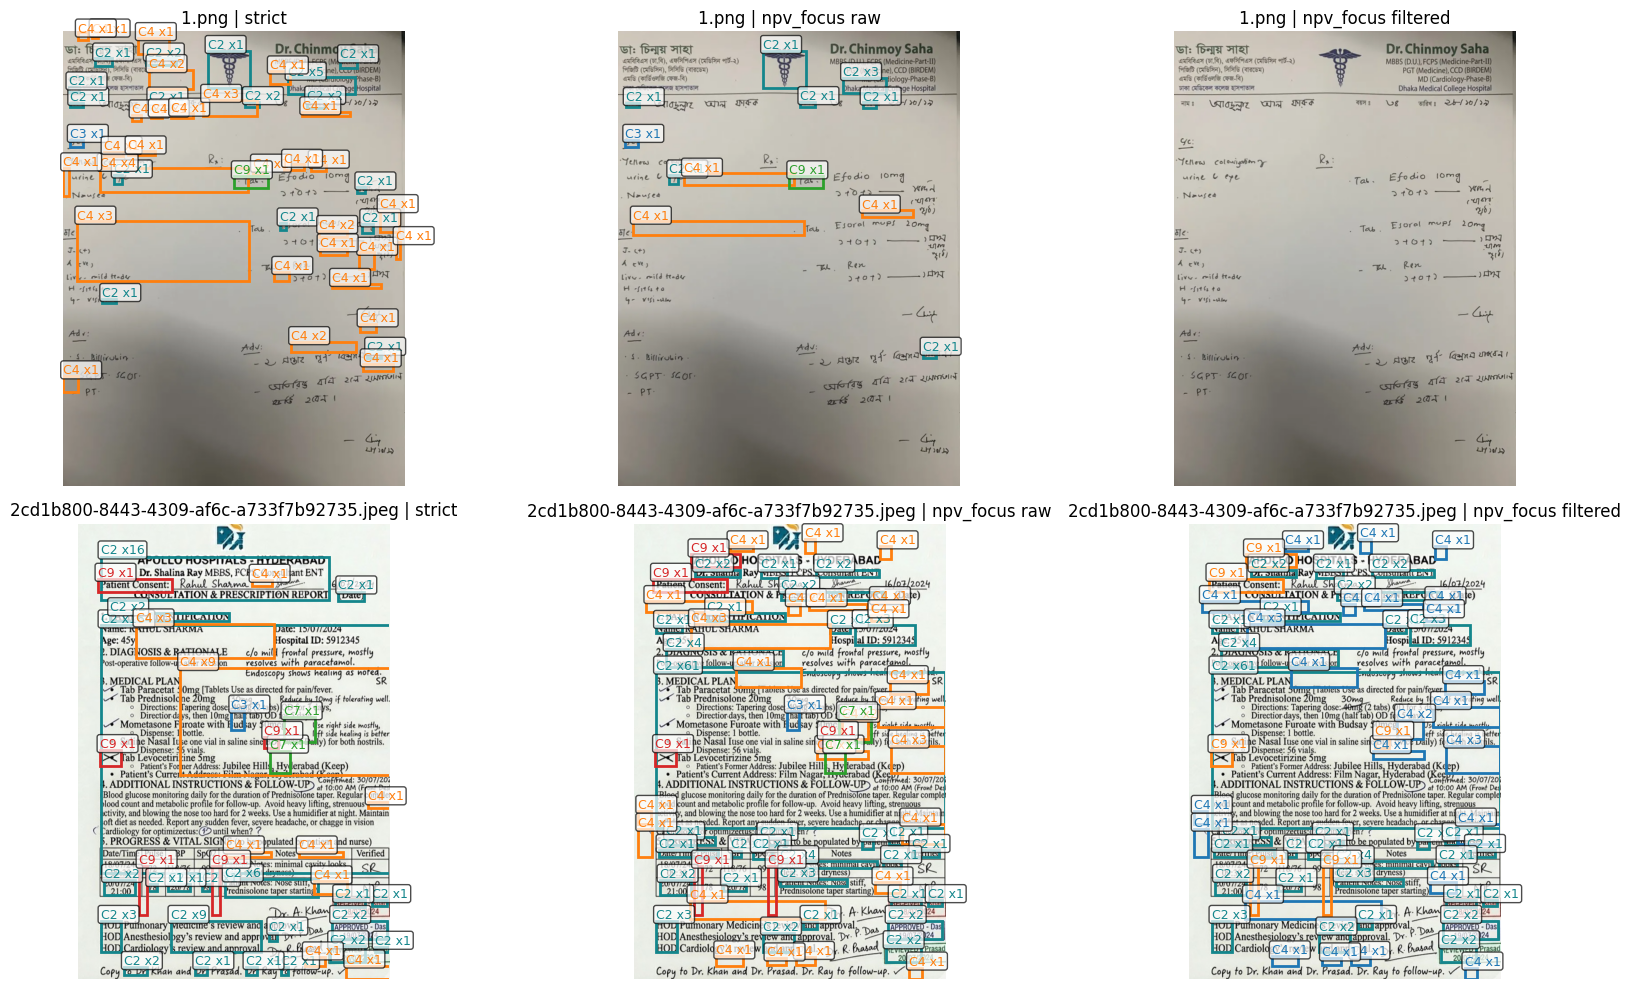

In [43]:
# Render images for strict, npv_focus (raw), and npv_focus (filtered) for both images
import os
from pathlib import Path
import sys
import copy
import shutil
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
repo_root = Path.cwd()
if not (repo_root / "backend").exists():
    repo_root = repo_root.parent
backend_dir = repo_root / "backend"
if str(backend_dir) not in sys.path:
    sys.path.insert(0, str(backend_dir))
fallback = Path(r"C:\Program Files\Tesseract-OCR\tesseract.exe")
found = os.environ.get("TESSERACT_CMD") or shutil.which("tesseract")
if not found and fallback.exists():
    found = str(fallback)
if found:
    os.environ["TESSERACT_CMD"] = found
from app.pipeline import run_pipeline, DETECTOR_TUNING, set_tuning_preset
IMAGE1 = Path(r"C:\Users\nikhi\Downloads\sample_data\1.png")
IMAGE2 = Path(r"C:\Users\nikhi\Downloads\sample_data\2cd1b800-8443-4309-af6c-a733f7b92735.jpeg")
base_work_dir = repo_root / "backend_sample_testing" / "work_fair" / "npv_vis_runs"
base_work_dir.mkdir(parents=True, exist_ok=True)
MERGE_GAP = 8
PADDING = 10
def boxes_close(a, b, gap: int) -> bool:
    return not (
        a[2] + gap < b[0]
        or b[2] + gap < a[0]
        or a[3] + gap < b[1]
        or b[3] + gap < a[1]
    )
def merge_box(a, b):
    return (min(a[0], b[0]), min(a[1], b[1]), max(a[2], b[2]), max(a[3], b[3]))
def merge_boxes(boxes, gap: int):
    clusters = [{"box": b, "count": 1} for b in boxes]
    if not clusters:
        return []
    changed = True
    while changed:
        changed = False
        merged = []
        while clusters:
            curr = clusters.pop()
            i = 0
            while i < len(clusters):
                if boxes_close(curr["box"], clusters[i]["box"], gap):
                    curr["box"] = merge_box(curr["box"], clusters[i]["box"])
                    curr["count"] += clusters[i]["count"]
                    clusters.pop(i)
                    changed = True
                else:
                    i += 1
            merged.append(curr)
        clusters = merged
    return clusters
def apply_npv_filter(results_list, pages_list, min_area_ratio=0.02, min_regions=4, focus_categories=None):
    focus_categories = focus_categories or {"C2", "C3", "C4", "C7", "C9", "C8"}
    page_map = {p.page_file_name: p for p in pages_list}
    filtered_results = []
    for res in results_list:
        page = page_map.get(res.file_name)
        page_area = None
        if page and page.image_width and page.image_height:
            page_area = float(page.image_width * page.image_height)
        category_area = defaultdict(float)
        category_count = defaultdict(int)
        for region in res.detected_regions:
            area = float(region.w * region.h)
            category_area[region.category_id] += area
            category_count[region.category_id] += 1
        keep_categories = []
        keep_regions = []
        for region in res.detected_regions:
            cat = region.category_id
            if cat in focus_categories and page_area:
                ratio = category_area[cat] / page_area
                if category_count[cat] < min_regions or ratio < min_area_ratio:
                    continue
            keep_regions.append(region)
        for cat in res.predicted_categories:
            if cat in focus_categories and page_area:
                ratio = category_area[cat] / page_area
                if category_count[cat] < min_regions or ratio < min_area_ratio:
                    continue
            keep_categories.append(cat)
        res.detected_regions = keep_regions
        res.predicted_categories = keep_categories or ["C10"]
        filtered_results.append(res)
    return filtered_results
def render_results(ax, page, result, title):
    image_path = Path(page.image_path or page.original_path)
    image = Image.open(image_path).convert("RGB")
    ax.imshow(image)
    palette = [
        "#14868C",
        "#1f77b4",
        "#ff7f0e",
        "#2ca02c",
        "#d62728",
        "#9467bd",
        "#8c564b",
        "#e377c2",
        "#7f7f7f",
        "#bcbd22",
    ]
    color_map = {}
    boxes_by_category = {}
    for region in result.detected_regions:
        box = (region.x, region.y, region.x + region.w, region.y + region.h)
        boxes_by_category.setdefault(region.category_id, []).append(box)
    for category_id, boxes in boxes_by_category.items():
        color = color_map.get(category_id)
        if color is None:
            color = palette[len(color_map) % len(palette)]
            color_map[category_id] = color
        clusters = merge_boxes(boxes, MERGE_GAP)
        for cluster in clusters:
            x1, y1, x2, y2 = cluster["box"]
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2.0, edgecolor=color, facecolor="none")
            ax.add_patch(rect)
            ax.text(
                x1,
                max(0, y1 - 6),
                f"{category_id} x{cluster['count']}",
                color=color,
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7),
            )
    ax.set_title(title)
    ax.axis("off")
def build_npv_focus_test():
    base = DETECTOR_TUNING.get('strict', DETECTOR_TUNING.get('normal'))
    npv_focus = copy.deepcopy(base)
    npv_focus['c2'].update({'edge_z': 3.6, 'stroke_z': 3.6, 'ocr_edge_density': 0.35, 'min_region_area': 260, 'min_line_components': 5, 'component_min_area': 170})
    npv_focus['c3'].update({'component_min_area': 320, 'min_candidate_area': 520, 'stamp_circularity': 0.72, 'stamp_fill': 0.38, 'signature_aspect': 5.0, 'signature_fill_max': 0.18, 'fill_min': 0.55, 'ocr_min_area': 260, 'min_region_area': 260})
    npv_focus['c4'].update({'gap_min_abs': 18.0, 'gap_median_mult': 2.6, 'gap_token_width_mult': 0.9, 'smooth_percentile': 20, 'smooth_min_area': 320, 'smooth_min_dim': 10, 'score_threshold': 3.2, 'min_region_area': 240})
    npv_focus['c7'].update({'min_tokens_page': 6, 'min_tokens_per_line': 6, 'min_gaps_per_line': 4})
    npv_focus['c8'].update({'score_threshold': 4.0, 'coverage_min': 0.5, 'line_coverage_min': 0.6, 'coverage_high_min': 0.75, 'spec_peak_min': 15.0, 'spec_highfreq_min': 3.0, 'text_density_min': 0.012})
    npv_focus['c9'].update({'z_edge': 3.0, 'z_grad': 3.0, 'z_res': 3.0, 'z_var': 3.0, 'z_stroke': 3.0, 'z_height': 3.2, 'score_threshold': 3.2, 'min_region_area': 200, 'min_line_tokens': 3})
    DETECTOR_TUNING['npv_focus_test'] = npv_focus
build_npv_focus_test()
modes = [
    ('strict', False, 'strict'),
    ('npv_focus_test', False, 'npv_focus raw'),
    ('npv_focus_test', True, 'npv_focus filtered'),
]
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
images = [IMAGE1, IMAGE2]
for row, img_path in enumerate(images):
    for col, (preset, do_filter, label) in enumerate(modes):
        set_tuning_preset(preset)
        run_dir = base_work_dir / f"{img_path.stem}_{label.replace(' ', '_')}"
        if run_dir.exists():
            shutil.rmtree(run_dir)
        run_dir.mkdir(parents=True, exist_ok=True)
        out = run_pipeline(img_path, run_dir, preset=preset, enable_ocr=True)
        pages = out.get('pages', [])
        results = out.get('results', [])
        if do_filter:
            results = apply_npv_filter(results, pages, min_area_ratio=0.02, min_regions=4)
        if not pages or not results:
            axes[row, col].set_title(f'{label} (no results)')
            axes[row, col].axis('off')
            continue
        title = f"{img_path.name} | {label}"
        render_results(axes[row, col], pages[0], results[0], title)
plt.tight_layout()
plt.show()

In [ ]:
# Clean config: npv_focus_filtered tuning + post-filter
import copy
from app.pipeline import DETECTOR_TUNING, set_tuning_preset
NPV_FOCUS_FILTERED_CONFIG = {
    'preset_base': 'strict',
    'tuning': {
        'c2': {
            'edge_z': 3.6,
            'stroke_z': 3.6,
            'ocr_edge_density': 0.35,
            'min_region_area': 260,
            'min_line_components': 5,
            'component_min_area': 170,
        },
        'c3': {
            'component_min_area': 320,
            'min_candidate_area': 520,
            'stamp_circularity': 0.72,
            'stamp_fill': 0.38,
            'signature_aspect': 5.0,
            'signature_fill_max': 0.18,
            'fill_min': 0.55,
            'ocr_min_area': 260,
            'min_region_area': 260,
        },
        'c4': {
            'gap_min_abs': 18.0,
            'gap_median_mult': 2.6,
            'gap_token_width_mult': 0.9,
            'smooth_percentile': 20,
            'smooth_min_area': 320,
            'smooth_min_dim': 10,
            'score_threshold': 3.2,
            'min_region_area': 240,
            'ring_var_ratio': 0.55,
            'ring_grad_ratio': 0.55,
            'ring_res_ratio': 0.6,
            'ring_fg_delta': 0.12,
            'erased_text_bonus': 0.3,
        },
        'c7': {
            'min_tokens_page': 6,
            'min_tokens_per_line': 6,
            'min_gaps_per_line': 4,
            'med_gap_min': 6.0,
            'mad_gap_min': 1.4,
            'gap_cv_max': 0.6,
            'min_token_width': 8,
            'large_gap_min_abs': 18.0,
            'large_gap_median_mult': 2.8,
            'large_gap_z': 4.2,
            'large_gap_line_ratio_max': 0.22,
            'tight_gap_median_mult': 0.34,
            'tight_gap_median_min': 12.0,
            'tight_gap_z': -3.6,
            'single_gap_median_mult': 4.6,
            'single_gap_min_abs': 28.0,
            'single_gap_min_tokens': 7,
        },
        'c8': {
            'score_threshold': 4.0,
            'coverage_min': 0.5,
            'line_coverage_min': 0.6,
            'coverage_high_min': 0.75,
            'spec_peak_min': 15.0,
            'spec_highfreq_min': 3.0,
            'text_density_min': 0.012,
        },
        'c9': {
            'z_edge': 3.0,
            'z_grad': 3.0,
            'z_res': 3.0,
            'z_var': 3.0,
            'z_stroke': 3.0,
            'z_height': 3.2,
            'score_threshold': 3.2,
            'min_region_area': 200,
            'min_line_tokens': 3,
        },
    },
    'filter': {
        'min_area_ratio': 0.02,
        'min_regions': 4,
        'focus_categories': ['C2', 'C3', 'C4', 'C7', 'C8', 'C9'],
    },
}
def apply_npv_focus_filtered_config():
    base_name = NPV_FOCUS_FILTERED_CONFIG['preset_base']
    base = DETECTOR_TUNING.get(base_name, DETECTOR_TUNING['normal'])
    tuned = copy.deepcopy(base)
    for key, updates in NPV_FOCUS_FILTERED_CONFIG['tuning'].items():
        tuned[key].update(updates)
    DETECTOR_TUNING['npv_focus_filtered'] = tuned
    set_tuning_preset('npv_focus_filtered')
    return tuned
print('npv_focus_filtered config ready:', NPV_FOCUS_FILTERED_CONFIG)